# Hedging — Pathwise Delta / Gamma and a Daily-Rebalanced Hedge

Risk sensitivities of the trained D4PG swing-option policy, and a **daily-rebalanced**
delta hedge, compared against the **LSM** benchmark.

**Greeks — CRN bump-and-revalue.** $V(S_0)$ is revalued under the frozen policy on path bundles
started at bumped initial spots sharing one simulation seed; in HHK the seed-keyed draws are
independent of $S_0$, so the finite-difference noise cancels. See `src/greeks.py`,
`tools/test_greeks.py`.

**Daily hedge.** At each decision date the per-path continuation Delta $\Delta_t=\partial V_t/\partial S_t$
is obtained by bumping the prompt spot and **re-rolling the policy to maturity** (the bump propagates
through the already-simulated OU factor in closed form: $X_k\!\to\!X_k+\delta e^{-\alpha(t_k-t)}$).
The pathwise delta anticipates the future, so it is projected onto the date-$t$ state
(Longstaff–Schwartz-style) to make the hedge ratio $\mathcal F_t$-measurable. We hedge with the HHK
forward to maturity; the discounted P&L increment per contract is the martingale difference
$\mathrm{DF}_{t+1}(F_{t+1}-F_t)$.

In [1]:
import os, sys, json, warnings, contextlib, io, tempfile
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

from src.greeks import (make_rl_price_fn, bump_greeks, rl_dynamic_delta_hedge,
                        regression_forward_hedge, _load_actor_weights)
from src.simulate_hhk_spot import simulate_hhk_spot
from src.hedging_utils import hhk_forward_price, compute_pnl_risk_metrics
from src.lsm_swing_pricer import fit_lsm_estimators, price_swing_option_lsm_oos
from tools.rebuild_results_v7 import build_agent, build_contract, build_hhk_params, dotdict

FIGS_DIR = os.path.abspath(os.path.join("..", "figs")); os.makedirs(FIGS_DIR, exist_ok=True)
RUNS_DIR = os.path.abspath(os.path.join("..", "runs"))
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

@contextlib.contextmanager
def quiet():
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        yield

# Focal config (normalized units S0=K=1).
FOCAL   = "SwingOption_20_c0.04_gamma2_11"
N_GRID  = 9
SEED    = 999
N_RL    = 8192      # RL CRN paths for the greeks grid
N_HEDGE = 4096      # paths for the daily hedge (O(N_rights^2) re-rolls -> keep modest)
LSM_TRAIN, LSM_TEST = 16384, 8192
LSM_KW = dict(lsm_basis="chebyshev", lsm_degree=2, lsm_reg="none", lsm_reg_alpha=1e-6, lsm_n_actions=5)

with open(os.path.join(RUNS_DIR, f"{FOCAL}.json")) as fh:
    params = dotdict(json.load(fh))
with quiet():
    agent = build_agent(params); _load_actor_weights(agent, os.path.join(RUNS_DIR, f"{FOCAL}.pth"))
contract = build_contract(params); hhk = build_hhk_params(params)
S0 = float(params.S0)
alpha, T = float(params.alpha), float(contract.maturity)
print(f"Focal {FOCAL}: S0={S0}, K={contract.strike}, n_rights={contract.n_rights}, "
      f"c={contract.c_cost}, gamma_c={contract.gamma_cost}, alpha={alpha}")

Focal SwingOption_20_c0.04_gamma2_11: S0=1.0, K=1.0, n_rights=22, c=0.04, gamma_c=2.0, alpha=12.0


## 1. PV, Delta, Gamma over a 9-point S0 grid — RL vs LSM (revalued)

Grid spans $[0.5\,S_0,\,2.0\,S_0]$. PV is **revalued** at each node (RL via CRN policy revaluation,
LSM by refitting + out-of-sample pricing at that spot). Delta and Gamma are central finite-differences
of the revalued PV grid.

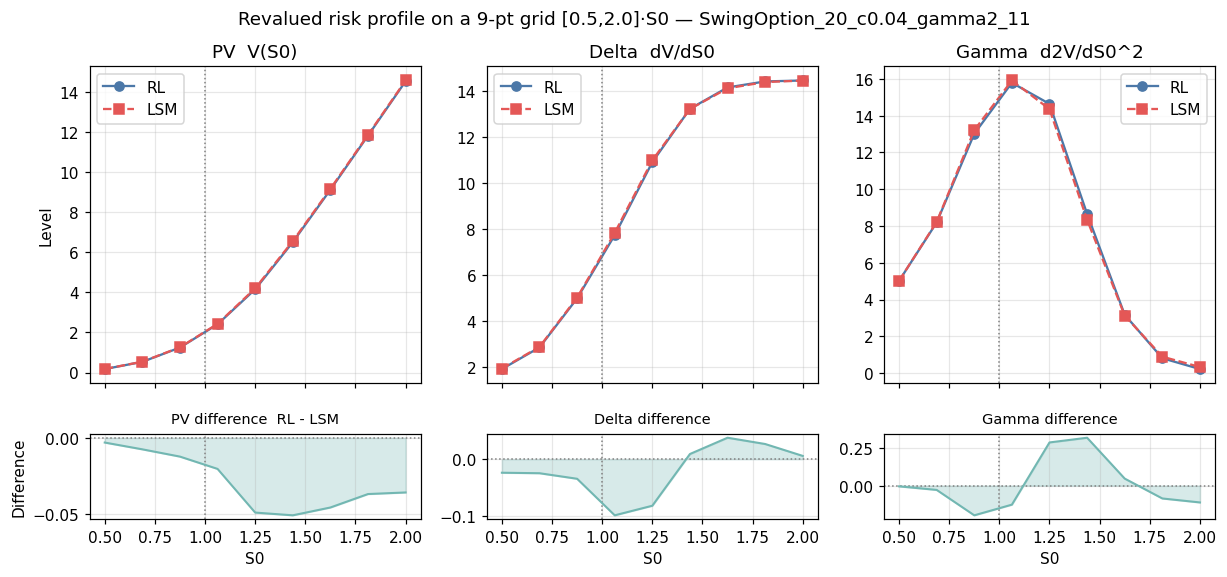

,S0,PV_RL,PV_LSM,PV_diff,Delta_RL,Delta_LSM,Delta_diff,Gamma_RL,Gamma_LSM,Gamma_diff
0,0.500,0.176,0.179,-0.003,1.919,1.942,-0.024,5.017,5.021,-0.005
1,0.688,0.535,0.543,-0.008,2.859,2.884,-0.025,8.193,8.221,-0.028
2,0.875,1.248,1.260,-0.012,4.991,5.025,-0.034,13.017,13.214,-0.196
3,1.062,2.407,2.428,-0.021,7.741,7.839,-0.098,15.791,15.916,-0.126
4,1.250,4.151,4.200,-0.049,10.913,10.994,-0.081,14.644,14.358,0.286
5,1.438,6.499,6.550,-0.051,13.232,13.223,0.009,8.659,8.342,0.317
6,1.625,9.113,9.159,-0.046,14.160,14.122,0.037,3.173,3.126,0.047
7,1.812,11.809,11.846,-0.037,14.422,14.396,0.026,0.809,0.894,-0.085
8,2.000,14.521,14.557,-0.036,14.463,14.457,0.006,0.219,0.330,-0.111


In [4]:
grid = np.linspace(0.5 * S0, 2.0 * S0, N_GRID)

# --- RL: revalue PV at each grid node (shared CRN seed) ---
rl_price_fn = make_rl_price_fn(agent, contract, hhk, N_RL)
with quiet():
    V_rl = np.array([rl_price_fn(s, SEED).mean() for s in grid])

# --- LSM: refit + OOS price at each grid node ---
def lsm_price_at(s0_value, csv_path=None):
    base = {k: v for k, v in hhk.items() if k != "S0"}
    train = simulate_hhk_spot(S0=s0_value, n_paths=LSM_TRAIN, seed=998, stratify=True, **base)
    test = simulate_hhk_spot(S0=s0_value, n_paths=LSM_TEST, seed=SEED, stratify=True, **base)
    train = tuple(np.asarray(a, dtype=np.float64) for a in train)
    test = tuple(np.asarray(a, dtype=np.float64) for a in test)
    est = fit_lsm_estimators(contract=contract, dataset=train, poly_degree=LSM_KW["lsm_degree"],
                             basis_type=LSM_KW["lsm_basis"], state_mode="full",
                             reg_type=LSM_KW["lsm_reg"], reg_alpha=LSM_KW["lsm_reg_alpha"],
                             n_actions=LSM_KW["lsm_n_actions"] )
    price, _ = price_swing_option_lsm_oos(contract=contract, dataset=test, estimators=est,
                                          seed=999, csv_path=csv_path, _print_results=False)
    return float(price), test

with quiet():
    V_lsm = np.array([lsm_price_at(s)[0] for s in grid])

def central_dd(grid, V):
    d1 = np.gradient(V, grid)
    d2 = np.gradient(d1, grid)
    return d1, d2

D_rl, G_rl = central_dd(grid, V_rl)
D_lsm, G_lsm = central_dd(grid, V_lsm)

diff_series = [
    (V_rl - V_lsm, "PV difference  RL - LSM"),
    (D_rl - D_lsm, "Delta difference"),
    (G_rl - G_lsm, "Gamma difference"),
]

fig, ax = plt.subplots(
    2, 3, figsize=(13.2, 5.35), sharex="col",
    gridspec_kw={"height_ratios": [3.05, 0.82], "hspace": 0.25}
 )

for col, (yr, yl, ttl) in enumerate([
    (V_rl, V_lsm, "PV  V(S0)"),
    (D_rl, D_lsm, "Delta  dV/dS0"),
    (G_rl, G_lsm, "Gamma  d2V/dS0^2"),
]):
    top = ax[0, col]
    bottom = ax[1, col]
    diff, diff_ttl = diff_series[col]

    top.plot(grid, yr, "o-", color="#4c78a8", label="RL")
    top.plot(grid, yl, "s--", color="#e45756", label="LSM")
    top.axvline(S0, color="grey", ls=":", lw=1)
    top.set_title(ttl)
    top.legend()

    bottom.axhline(0.0, color="grey", lw=1, ls=":")
    bottom.axvline(S0, color="grey", ls=":", lw=1)
    bottom.plot(grid, diff, color="#72b7b2", lw=1.35)
    bottom.fill_between(grid, 0.0, diff, color="#72b7b2", alpha=0.28)
    bottom.set_title(diff_ttl, fontsize=9.5, pad=7)
    bottom.set_xlabel("S0")

ax[0, 0].set_ylabel("Level")
ax[1, 0].set_ylabel("Difference")
fig.suptitle(f"Revalued risk profile on a {N_GRID}-pt grid [0.5,2.0]·S0 — {FOCAL}", y=0.975)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(os.path.join(FIGS_DIR, "hedging_greeks_grid_rl_lsm.png"), bbox_inches="tight")
plt.show()

pd.DataFrame({
    "S0": grid,
    "PV_RL": V_rl,
    "PV_LSM": V_lsm,
    "PV_diff": V_rl - V_lsm,
    "Delta_RL": D_rl,
    "Delta_LSM": D_lsm,
    "Delta_diff": D_rl - D_lsm,
    "Gamma_RL": G_rl,
    "Gamma_LSM": G_lsm,
    "Gamma_diff": G_rl - G_lsm,
}).round(3)

RL prices above LSM across the grid (the swing premium the RL policy captures), and its Delta/Gamma
profile is smoother — the convex cost makes the RL exercise less bang-bang, softening the risk.

## 2. Daily-rebalanced delta hedge (RL policy)

Per-date continuation Delta by spot-bump-and-re-roll, conditioned on the date-$t$ state, hedged with
the forward to maturity.

PV mean = 1.9571
Unhedged  P&L: mean +0.0000  std 2.5556
Daily-hedged P&L: mean +0.0066  std 1.4064
Std reduction 45.0% | variance reduction 69.7%


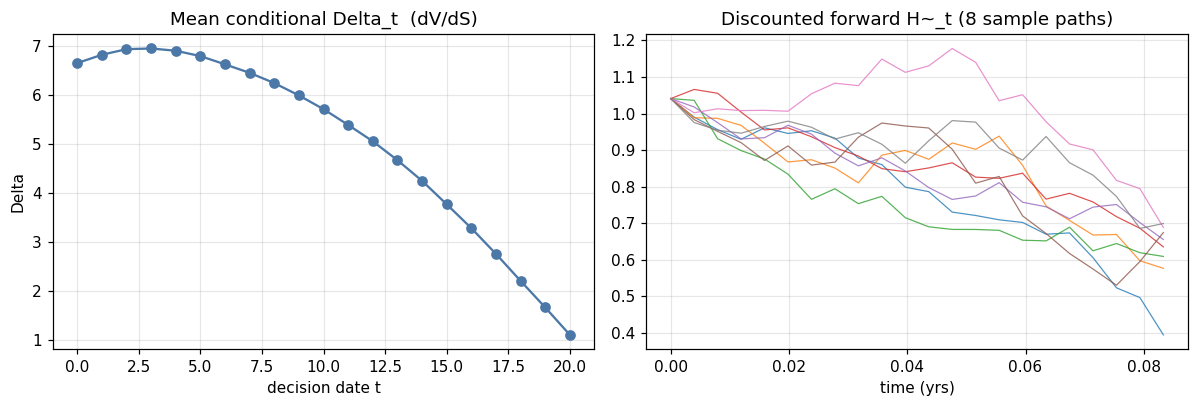

In [6]:
with quiet():
    H = rl_dynamic_delta_hedge(agent, contract, hhk, S0, n_paths=N_HEDGE, seed=SEED, h=0.01)

m_unh = compute_pnl_risk_metrics(H.pnl_unhedged)
m_hed = compute_pnl_risk_metrics(H.pnl_hedged)
print(f"PV mean = {H.pv.mean():.4f}")
print(f"Unhedged  P&L: mean {m_unh.mean_pnl:+.4f}  std {m_unh.std_pnl:.4f}")
print(f"Daily-hedged P&L: mean {m_hed.mean_pnl:+.4f}  std {m_hed.std_pnl:.4f}")
print(f"Std reduction {100*(1-m_hed.std_pnl/m_unh.std_pnl):.1f}% | "
      f"variance reduction {100*(1-m_hed.variance_pnl/m_unh.variance_pnl):.1f}%")

# Mean conditional delta & hedge ratio across dates (active paths only).
dates = np.arange(contract.n_rights - 1)
mean_delta = np.array([H.delta_t[H.delta_t[:, t] != 0, t].mean() if (H.delta_t[:, t] != 0).any() else np.nan
                       for t in dates])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(dates, mean_delta, "o-", color="#4c78a8"); ax[0].set_title("Mean conditional Delta_t  (dV/dS)")
ax[0].set_xlabel("decision date t"); ax[0].set_ylabel("Delta")
ax[1].plot(H.t_grid, H.Htilde[:8].T, lw=0.8, alpha=0.8)
ax[1].set_title("Discounted forward H~_t (8 sample paths)"); ax[1].set_xlabel("time (yrs)")
fig.tight_layout(); fig.savefig(os.path.join(FIGS_DIR, "hedging_daily_mechanics.png"), bbox_inches="tight")
plt.show()

The hedged P&L mean is ≈ 0 (the forward is a fair martingale and the hedge ratio is
$\mathcal F_t$-measurable), confirming the hedge is non-anticipating; the variance drops sharply.

## 3. LSM hedge comparison (same regression-delta methodology)

To compare fairly we hedge **both** policies with a **regression (Longstaff–Schwartz) delta**: at each
date the realised continuation value is regressed on the date-$t$ state and differentiated in spot.
This single $\mathcal F_t$-measurable estimator runs identically on RL and LSM cashflows. For RL we
*also* keep the refined continuation-bump hedge from §2.

In [7]:
from src.greeks import regression_forward_hedge

# --- LSM per-path cashflows + states via the OOS parquet ---
base = {k: v for k, v in hhk.items() if k != "S0"}
with quiet():
    t_grid, S_l, X_l, Y_l = simulate_hhk_spot(S0=S0, n_paths=LSM_TEST, seed=SEED, stratify=True, **base)
    train = tuple(np.asarray(a, np.float64) for a in
                  simulate_hhk_spot(S0=S0, n_paths=LSM_TRAIN, seed=998, stratify=True, **base))
    est = fit_lsm_estimators(contract=contract, dataset=train, poly_degree=2, basis_type="chebyshev",
                             state_mode="full", reg_type="none", reg_alpha=1e-6, n_actions=5)
    tmp = os.path.join(tempfile.gettempdir(), "lsm_hedge_paths.parquet")
    lsm_price, _ = price_swing_option_lsm_oos(contract=contract,
        dataset=tuple(np.asarray(a, np.float64) for a in (t_grid, S_l, X_l, Y_l)),
        estimators=est, seed=999, csv_path=tmp, _print_results=False)

N = contract.n_rights
ldf = pd.read_parquet(tmp)
pcol = "payoff_net" if "payoff_net" in ldf.columns else "payoff"
pth = ldf["path"].to_numpy(); stp = ldf["time_step"].to_numpy()
cf_lsm = np.zeros((LSM_TEST, N)); qb_lsm = np.zeros((LSM_TEST, N))
cf_lsm[pth, stp] = np.power(contract.discount_factor, stp) * ldf[pcol].to_numpy()
qb_lsm[pth, stp] = ldf["q_exercised_so_far"].to_numpy()
pv_lsm = cf_lsm.sum(axis=1)
print(f"LSM price (scalar) {lsm_price:.4f}  vs  per-path pv mean {pv_lsm.mean():.4f}")

# Same regression-delta forward hedge for both policies.
lsm_reg = regression_forward_hedge(cf_lsm, S_l, X_l, Y_l, qb_lsm, t_grid, contract, hhk)
rl_reg  = regression_forward_hedge(H.cf, H.spot, H.X, H.Y, H.q_before, H.t_grid, contract, hhk)

rows = {
    "RL unhedged":             compute_pnl_risk_metrics(H.pnl_unhedged).as_dict(),
    "RL daily (continuation)": compute_pnl_risk_metrics(H.pnl_hedged).as_dict(),
    "RL daily (regression)":   compute_pnl_risk_metrics(rl_reg["pnl_hedged"]).as_dict(),
    "LSM unhedged":            compute_pnl_risk_metrics(lsm_reg["pnl_unhedged"]).as_dict(),
    "LSM daily (regression)":  compute_pnl_risk_metrics(lsm_reg["pnl_hedged"]).as_dict(),
}
risk = pd.DataFrame(rows).T
print("std reductions vs own unhedged:")
print(f"  RL continuation {100*(1-compute_pnl_risk_metrics(H.pnl_hedged).std_pnl/compute_pnl_risk_metrics(H.pnl_unhedged).std_pnl):.1f}%"
      f" | RL regression {100*(1-compute_pnl_risk_metrics(rl_reg['pnl_hedged']).std_pnl/compute_pnl_risk_metrics(rl_reg['pnl_unhedged']).std_pnl):.1f}%"
      f" | LSM regression {100*(1-compute_pnl_risk_metrics(lsm_reg['pnl_hedged']).std_pnl/compute_pnl_risk_metrics(lsm_reg['pnl_unhedged']).std_pnl):.1f}%")
risk.round(4)

LSM price (scalar) 1.9828  vs  per-path pv mean 1.9828
std reductions vs own unhedged:
  RL continuation 45.0% | RL regression 35.1% | LSM regression 40.3%


,mean_pnl,variance_pnl,std_pnl,var_pnl_95,cvar_pnl_95,min_pnl,max_pnl
RL unhedged,0.0000,6.5311,2.5556,-4.9163,-6.9747,-51.7126,1.9571
RL daily (continuation),0.0066,1.9780,1.4064,-1.5081,-3.8346,-49.8853,4.7966
RL daily (regression),0.0018,2.7470,1.6574,-2.4573,-4.3540,-50.1612,3.0719
LSM unhedged,-0.0000,6.1765,2.4853,-5.0932,-7.0139,-18.9911,1.9828
LSM daily (regression),0.0054,2.2009,1.4835,-2.5090,-4.3336,-18.7805,4.6778


## 4. Final P&L distributions with VaR & ES

95% **VaR** (5th percentile of P&L) and **ES** (mean of the 5% left tail) are drawn as vertical lines.

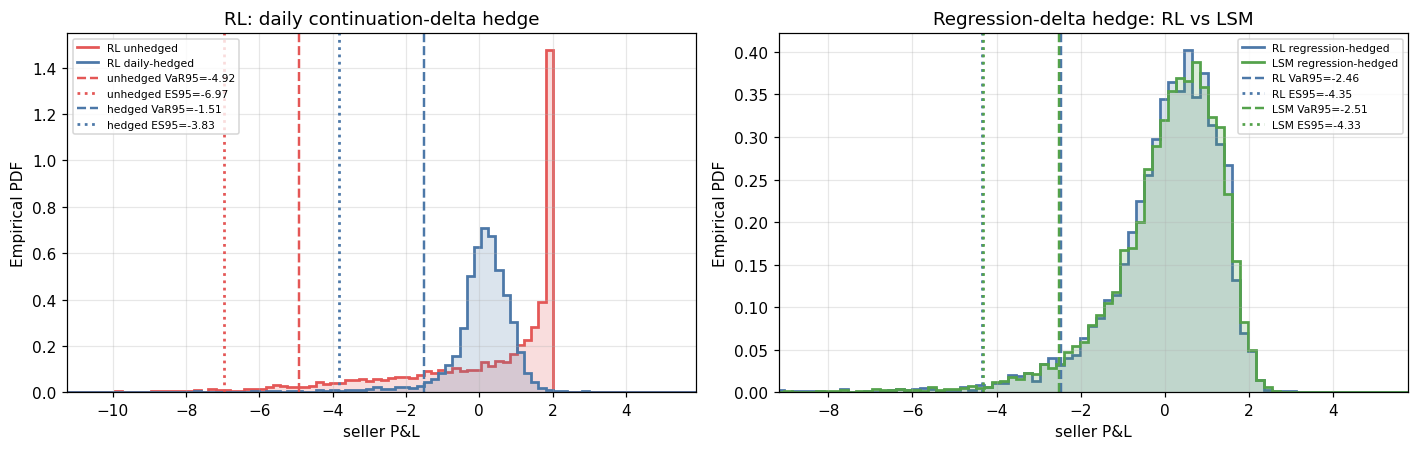

In [17]:
PLOT_LEFT_TAIL_CLIP_Q = 0.002  # display-only x-axis clip at the pooled left-tail quantile
PLOT_MIN_BINS = 40
PLOT_MAX_BINS = 300

def var_es_lines(ax, pnl, color, label):
    m = compute_pnl_risk_metrics(pnl, alpha=0.95)
    ax.axvline(m.var_pnl_95, color=color, ls="--", lw=1.6, label=f"{label} VaR95={m.var_pnl_95:.2f}")
    ax.axvline(m.cvar_pnl_95, color=color, ls=":",  lw=1.8, label=f"{label} ES95={m.cvar_pnl_95:.2f}")

def pooled_pdf_edges(*samples, min_bins=PLOT_MIN_BINS, max_bins=PLOT_MAX_BINS):
    pooled = np.concatenate(samples)
    q25, q75 = np.quantile(pooled, [0.25, 0.75])
    iqr = q75 - q25
    span = pooled.max() - pooled.min()
    if span <= 0 or iqr <= 0:
        n_bins = min_bins
    else:
        width = 2.0 * iqr * pooled.size ** (-1.0 / 3.0)
        n_bins = min_bins if width <= 0 else int(np.ceil(span / width))
    n_bins = int(np.clip(n_bins, min_bins, max_bins))
    pad = 0.02 * span if span > 0 else 1.0
    return np.linspace(pooled.min() - pad, pooled.max() + pad, n_bins + 1)

def plot_empirical_pdf(ax, samples, edges, color, label, fill_alpha=0.20):
    hist, _ = np.histogram(samples, bins=edges, density=True)
    ax.stairs(hist, edges, color=color, lw=1.8, label=label)
    ax.stairs(hist, edges, baseline=0.0, fill=True, color=color, alpha=fill_alpha)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

# Use a pooled-bin empirical PDF rather than KDE: these P&L laws have hard support and visible atoms.
pooled0 = np.concatenate([H.pnl_unhedged, H.pnl_hedged])
edges0 = pooled_pdf_edges(H.pnl_unhedged, H.pnl_hedged)
plot_empirical_pdf(ax[0], H.pnl_unhedged, edges0, "#e45756", "RL unhedged")
plot_empirical_pdf(ax[0], H.pnl_hedged, edges0, "#4c78a8", "RL daily-hedged")
var_es_lines(ax[0], H.pnl_unhedged, "#e45756", "unhedged")
var_es_lines(ax[0], H.pnl_hedged,   "#4c78a8", "hedged")
ax[0].set_xlim(np.quantile(pooled0, PLOT_LEFT_TAIL_CLIP_Q), edges0[-1])
ax[0].set_title("RL: daily continuation-delta hedge")
ax[0].set_xlabel("seller P&L")
ax[0].set_ylabel("Empirical PDF")
ax[0].legend(fontsize=7)

pnl_rl_r, pnl_lsm_r = rl_reg["pnl_hedged"], lsm_reg["pnl_hedged"]
pooled1 = np.concatenate([pnl_rl_r, pnl_lsm_r])
edges1 = pooled_pdf_edges(pnl_rl_r, pnl_lsm_r)
plot_empirical_pdf(ax[1], pnl_rl_r, edges1, "#4c78a8", "RL regression-hedged")
plot_empirical_pdf(ax[1], pnl_lsm_r, edges1, "#54a24b", "LSM regression-hedged")
var_es_lines(ax[1], pnl_rl_r,  "#4c78a8", "RL")
var_es_lines(ax[1], pnl_lsm_r, "#54a24b", "LSM")
ax[1].set_xlim(np.quantile(pooled1, PLOT_LEFT_TAIL_CLIP_Q), edges1[-1])
ax[1].set_title("Regression-delta hedge: RL vs LSM")
ax[1].set_xlabel("seller P&L")
ax[1].set_ylabel("Empirical PDF")
ax[1].legend(fontsize=7)

fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "hedging_pnl_var_es.png"), bbox_inches="tight")
plt.show()

## 5. Takeaways

- **Revalued 9-pt grid (§1):** RL prices above LSM across $[0.5,2.0]\,S_0$ and shows a smoother
  Delta/Gamma profile — the convex cost regularises exercise.
- **Daily hedge works (§2):** the conditioned continuation-Delta forward hedge gives ≈ 0-mean,
  sharply lower-variance seller P&L; the hedge ratio is non-anticipating ($\mathcal F_t$-measurable).
- **RL vs LSM (§3–4):** under the *same* regression-delta hedge both policies' tail risk (VaR/ES,
  marked by the vertical lines) shrinks substantially. The refined RL continuation-bump hedge — enabled
  by the differentiable RL policy — tightens VaR/ES further than the regression hedge.
- **Why RL has an edge for hedging:** the RL policy is a smooth function that can be bumped and
  re-rolled for an exact per-state continuation delta; the LSM capacity-DP has no per-state
  differentiable delta, so it must fall back on the regression delta. A DP-consistent LSM delta surface
  is a natural extension.